In [1]:
# INSTALLING REQUIRED LIBRARIES
!pip install -U pyproj -q
!pip install -U utm -q
!pip install -U google-colab -q
!pip install -U tornado -q
!pip install geemap -q
!pip install wxee

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 437.2/437.2 kB 3.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires tornado==6.4.2, but you have tornado 6.5.2 which is incompatible.


In [2]:
!pip install rioxarray pyproj

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
!ls /content/drive/MyDrive/insar/2021

OPERA_L3_DISP-S1_IW_F20697_VV_20210113T005116Z_20210125T005115Z_v1.0_20250418T132023Z.nc
OPERA_L3_DISP-S1_IW_F20697_VV_20210113T005116Z_20210206T005115Z_v1.0_20250418T132023Z.nc
OPERA_L3_DISP-S1_IW_F20697_VV_20210113T005116Z_20210218T005114Z_v1.0_20250418T132023Z.nc
OPERA_L3_DISP-S1_IW_F20697_VV_20210113T005116Z_20210302T005114Z_v1.0_20250418T132023Z.nc
OPERA_L3_DISP-S1_IW_F20697_VV_20210113T005116Z_20210314T005114Z_v1.0_20250418T132023Z.nc
OPERA_L3_DISP-S1_IW_F20697_VV_20210113T005116Z_20210326T005115Z_v1.0_20250418T132023Z.nc
OPERA_L3_DISP-S1_IW_F20697_VV_20210113T005116Z_20210407T005115Z_v1.0_20250418T132023Z.nc
OPERA_L3_DISP-S1_IW_F20697_VV_20210113T005116Z_20210419T005115Z_v1.0_20250418T132023Z.nc
OPERA_L3_DISP-S1_IW_F20697_VV_20210113T005116Z_20210501T005116Z_v1.0_20250418T132023Z.nc
OPERA_L3_DISP-S1_IW_F20697_VV_20210113T005116Z_20210513T005117Z_v1.0_20250418T132023Z.nc
OPERA_L3_DISP-S1_IW_F20697_VV_20210113T005116Z_20210525T005117Z_v1.0_20250418T132023Z.nc
OPERA_L3_DISP-S1_IW_F

In [5]:
import xarray as xr

ds = xr.open_dataset('/content/drive/MyDrive/insar/2021/OPERA_L3_DISP-S1_IW_F40297_VV_20210903T005940Z_20220507T010021Z_v1.0_20250418T114525Z.nc')

import xarray as xr
import rioxarray
from rasterio.warp import calculate_default_transform
import numpy as np

# Open dataset and select displacement
#ds = xr.open_dataset("OPERA_L3_DISP-S1_IW_F22664_VV_20240527T125538Z_20241111T125537Z_v1.0_20250420T162803Z.nc")
disp = ds["displacement"]

# Set CRS using rioxarray
disp = disp.rio.write_crs("EPSG:32613") # Check this always

# Reproject to regular lat/lon grid (WGS84)
disp_latlon = disp.rio.reproject("EPSG:4326")

# Now create dataset with 1D lat/lon coords
# These will still be 2D, so reduce them
lat_1d = np.unique(disp_latlon.y.values)
lon_1d = np.unique(disp_latlon.x.values)

# Reassign with 1D coords
disp_1d = xr.DataArray(
    data=disp_latlon.values,
    dims=("lat", "lon"),
    coords={"lat": lat_1d, "lon": lon_1d},
    name="displacement"
)

# Wrap in Dataset
ds_1d = xr.Dataset({"displacement": disp_1d})

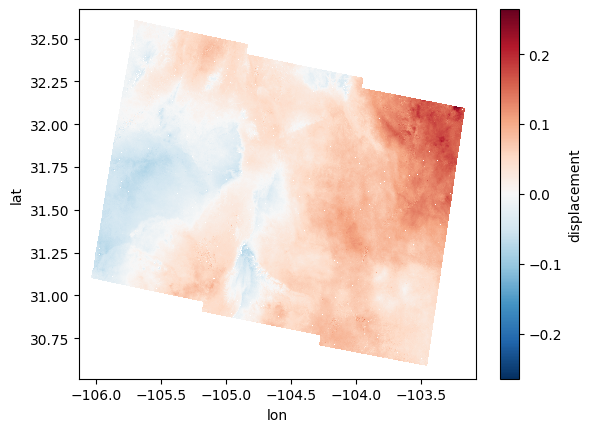

In [6]:
ds_1d.displacement.plot()

In [7]:
start_date = '20210903T005940Z'
end_date = '20220507T010021Z'

In [8]:
# !earthengine authenticate
import ee
import os

# Set the path to the service account key file
service_account = 'editor@ee-manmeet20singh15-wbis.iam.gserviceaccount.com'
key_file = 'drive/MyDrive/earth_engine/ee-manmeet20singh15-wbis-fab7f1ca35e0.json'

# Use the service account for authentication
credentials = ee.ServiceAccountCredentials(service_account, key_file)
ee.Initialize(credentials)

In [9]:
import ee
import wxee
#wxee.Initialize()

In [10]:
lat_diff = 0
lon_diff = 0
aoi = ee.Geometry.Polygon(
        [[[ds_1d.lon.values.max(), ds_1d.lat.values.min()],
          [ds_1d.lon.values.min(), ds_1d.lat.values.min()],
          [ds_1d.lon.values.min(), ds_1d.lat.values.max()],
          [ds_1d.lon.values.max(), ds_1d.lat.values.max()]]])

In [11]:
coords = aoi.coordinates().getInfo()[0]
coords

[[-106.13584199327694, 30.51365067964106],
 [-103.07728629474207, 30.51365067964106],
 [-103.07728629474207, 32.671437706448614],
 [-106.13584199327694, 32.671437706448614],
 [-106.13584199327694, 30.51365067964106]]

In [12]:
start_date = '2021-09-03' # start date from above
end_date = '2021-09-15' # start date + 12 days
dataset = ee.ImageCollection('COPERNICUS/S1_GRD') \
            .filterDate(start_date, end_date)
ds_s1 = dataset.wx.to_xarray(region=aoi.bounds(), scale=500) # 30 m is our target

Requesting data:   0%|          | 0/13968 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
ds_s1.to_netcdf('s1_2021_09_03_start.nc')

In [13]:
start_date = '2022-05-07' # end date from above
end_date = '2022-05-19' # start date + 12 days
dataset = ee.ImageCollection('COPERNICUS/S1_GRD') \
            .filterDate(start_date, end_date)
ds_s1 = dataset.wx.to_xarray(region=aoi.bounds(), scale=500) # 30 m is our target

Requesting data:   0%|          | 0/6839 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
ds_s1.to_netcdf('s1_2022_05_19_end.nc')